## Plot Results

This notebook is intended to generate plots and videos for the GP-MPC controller. 

Import all necessary libraries first.

In [149]:
# Libaries
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
plt.style.use(["science", "no-latex"])
import torch
import gpytorch
torch.set_default_dtype(torch.float64)
import numpy as np
import warnings
import os
import cv2
import numpy as np
import shutil
from tqdm import tqdm



# SmallsatSim stuff
from smallsat_sim.utils.logger import Logger
import matplotlib.pyplot as plt

# Zero Order GPMPC package stuff
from zero_order_gpmpc.models.gpytorch_models.gpytorch_gp import (
    BatchIndependentMultitaskGPModel,
)

Load the correct data (i.e. log file) and extract all the necessary things

In [150]:
# Create Logger object (needed to load data)
logger = Logger()

# Load the pandas dataframe
df = logger.load_log()

# Print some information about the df
df.shape
df.info()
df.describe()

Loading log files from directory: /Users/ahansson/Repos/smallsat-steward/smallsat_sim/../logs/2024-09-26_09:02:59
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RunID           1011 non-null   int64  
 1   Timestamp       1011 non-null   float64
 2   gp_GT           1011 non-null   object 
 3   gp_pred         1011 non-null   object 
 4   gp_lower        1011 non-null   object 
 5   gp_upper        1011 non-null   object 
 6   n_points_GP     1011 non-null   int64  
 7   e_gp            1011 non-null   float64
 8   e_nom           1011 non-null   float64
 9   tracking_error  1011 non-null   float64
 10  attitude_error  1011 non-null   float64
 11  solve_time      1011 non-null   int64  
 12  mpc_cost        1011 non-null   object 
 13  u_demanded      1011 non-null   object 
 14  velocity        1011 non-null   float64
 15  u_actual 

,RunID,Timestamp,n_points_GP,e_gp,e_nom,tracking_error,attitude_error,solve_time,velocity
count,1011.0,1011.000000,1011.000000,1011.000000,1011.000000,1011.000000,1011.000000,1011.0,1011.000000
mean,0.0,50.500000,243.571711,0.001792,0.010928,0.175455,76.239842,0.0,0.175805
std,0.0,29.199486,83.370054,0.003412,0.011666,0.157039,34.792234,0.0,0.056015
min,0.0,0.000000,1.000000,0.000000,0.000000,0.003061,22.520033,0.0,0.000000
25%,0.0,25.250000,209.000000,0.000188,0.001031,0.036222,51.899946,0.0,0.156543
50%,0.0,50.500000,300.000000,0.000526,0.006568,0.144907,66.857117,0.0,0.196538
75%,0.0,75.750000,300.000000,0.001553,0.017611,0.269503,84.915608,0.0,0.210871
max,0.0,101.000000,300.000000,0.033344,0.054476,0.616072,170.200769,0.0,0.254485


## Average Learning Performance

We quantify the learning performance by comparing the 2-norm of the model error with respect to the nominal model:

$$
\| e_{\text{nom}} \| = \| \mathbf{x}_{k+1} - f(\mathbf{x}_k, \mathbf{u}_k) \|
$$

and with respect to the corrected system dynamics:

$$
\| e_{\text{GP}} \| = \| \mathbf{x}_{k+1} - \left(f(\mathbf{x}_k, \mathbf{u}_k) + B_d \tilde{\mu}^d(\mathbf{z}_k)\right) \|.
$$


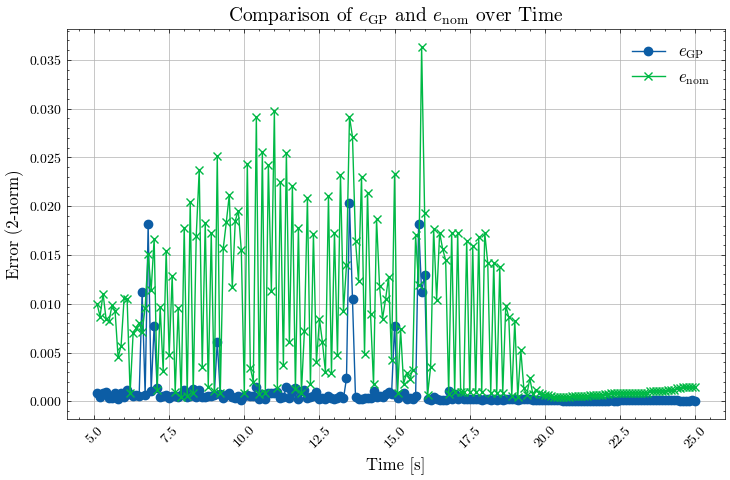

Quantity  Average  Std Dev      Min      Max
    e_gp 0.000998 0.002847 0.000047 0.020309
   e_nom 0.007872 0.008328 0.000433 0.036313


In [151]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 5
END_TIME = 25

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'
df_clean = df[['Timestamp', 'e_gp', 'e_nom']].dropna()

# Filter based on start_time and end_time if provided
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    if END_TIME > (max_timestamp := df_clean['Timestamp'].max()):
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

# Plotting the values
plt.figure(figsize=(7.5, 5))
plt.plot(df_clean['Timestamp'], df_clean['e_gp'], label=r'$e_{\text{GP}}$', marker='o')
plt.plot(df_clean['Timestamp'], df_clean['e_nom'], label=r'$e_{\text{nom}}$', marker='x')
plt.title(r'Comparison of $e_{\text{GP}}$ and $e_{\text{nom}}$ over Time', fontsize=14)
plt.xlabel(r'Time [s]', fontsize=12)
plt.ylabel(r'Error (2-norm)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

# Create a table
# Calculate statistics for e_gp and e_nom
stats = {
    'Quantity': ['e_gp', 'e_nom'],
    'Average': [df_clean['e_gp'].mean(), df_clean['e_nom'].mean()],
    'Std Dev': [df_clean['e_gp'].std(), df_clean['e_nom'].std()],
    'Min': [df_clean['e_gp'].min(), df_clean['e_nom'].min()],
    'Max': [df_clean['e_gp'].max(), df_clean['e_nom'].max()]
}

# Create a pandas DataFrame to display the statistics in a table
stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

# Generate LaTeX table
latex_table = stats_df.to_latex(index=False, float_format="%.3f")

## Recorded Model Error in Specific Output Dimension

Plots the predicted model error of a specific output dimension over time in blue. Further the $2\sigma$ confidence bounds are plotted in light blue.


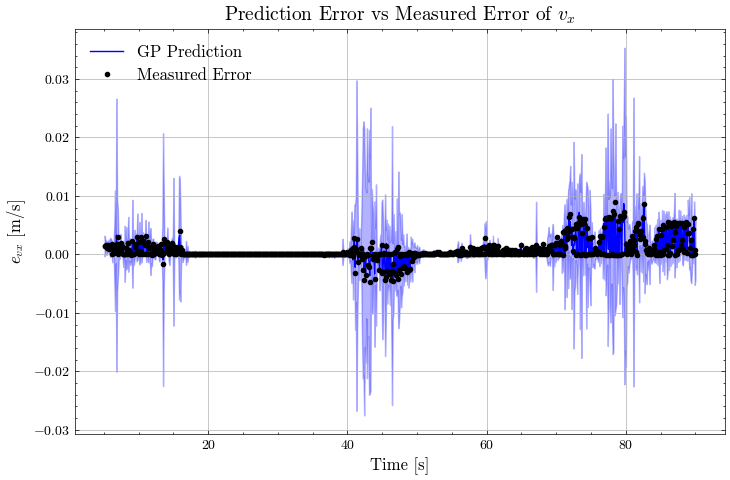

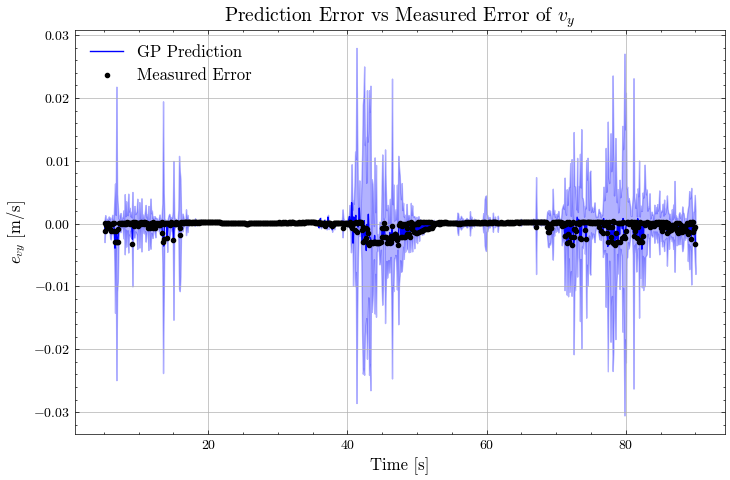

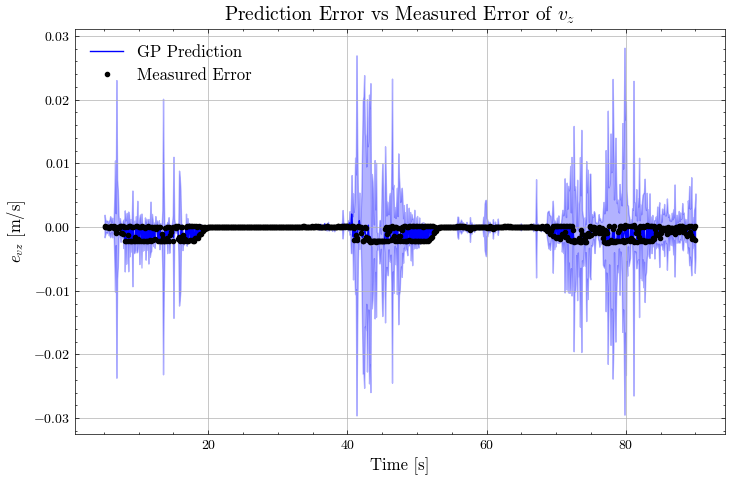

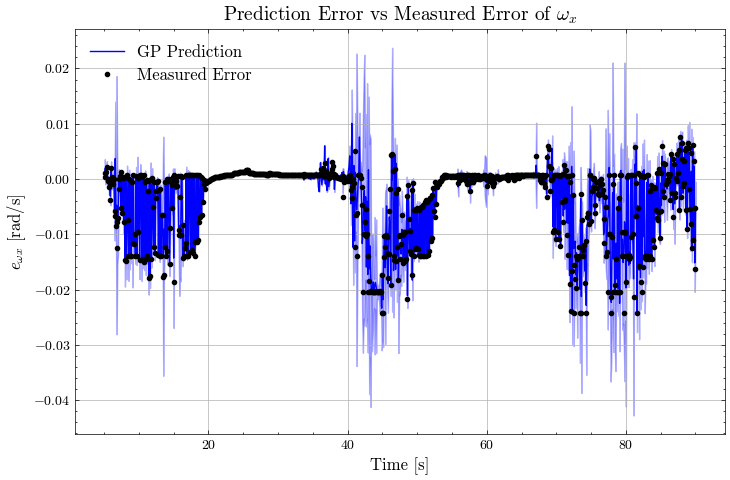

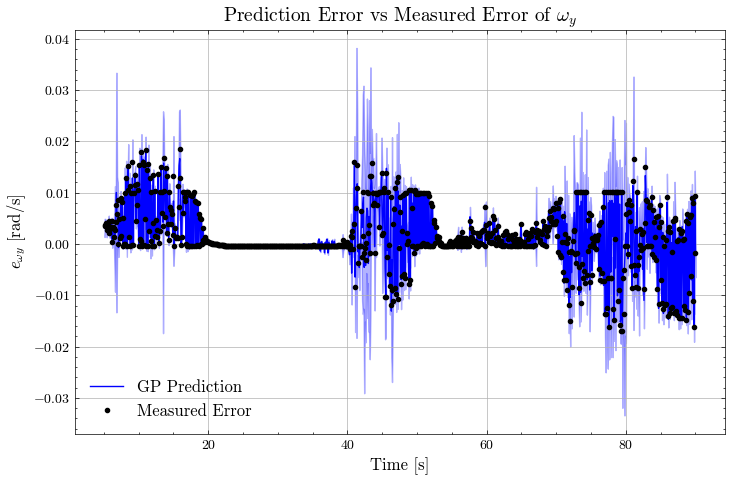

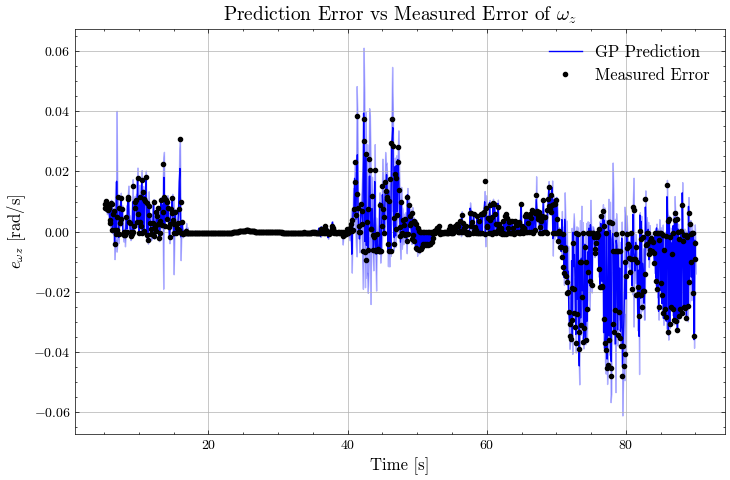

In [159]:
# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 70
END_TIME = 90

def plot_gp_component(df_clean, index, title, ylabel):
    """
    Plots the GP prediction and confidence interval for a specific component.
    """

    # Extract the specific component for each DataFrame column
    gp_pred_component = df_clean['gp_pred'].apply(lambda x: x[index])
    gp_GT_component = df_clean['gp_GT'].apply(lambda x: x[index])
    gp_upper_component = df_clean['gp_upper'].apply(lambda x: x[index])
    gp_lower_component = df_clean['gp_lower'].apply(lambda x: x[index])

    # Plot
    plt.figure(figsize=(7.5, 5))
    plt.plot(df_clean['Timestamp'], gp_pred_component, "b", label="GP Prediction")  # Mean prediction in blue
    plt.fill_between(df_clean['Timestamp'], gp_lower_component, gp_upper_component, alpha=0.3, color='blue')  # Confidence interval
    plt.plot(df_clean['Timestamp'], gp_GT_component, "k.", label="Measured Error")  # Ground truth data in black

    plt.xlabel("Time [s]", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'
df_clean = df[['Timestamp', 'gp_pred', 'gp_GT', 'gp_upper', 'gp_lower']].dropna()

# Filter based on start_time and end_time if provideds
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    if END_TIME > (max_timestamp := df_clean['Timestamp'].max()):
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]


# Define the components and titles for each component
components = [
    (0, r"Prediction Error vs Measured Error of $v_{x}$", r"$e_{vx}$ [m/s]"),
    (1, r"Prediction Error vs Measured Error of $v_{y}$", r"$e_{vy}$ [m/s]"),
    (2, r"Prediction Error vs Measured Error of $v_{z}$", r"$e_{vz}$ [m/s]"),
    (3, r"Prediction Error vs Measured Error of $\omega_{x}$", r"$e_{\omega x}$ [rad/s]"),
    (4, r"Prediction Error vs Measured Error of $\omega_{y}$", r"$e_{\omega y}$ [rad/s]"),
    (5, r"Prediction Error vs Measured Error of $\omega_{z}$", r"$e_{\omega z}$ [rad/s]"),
]

# Loop through each component and plot
for index, title, ylabel in components:
    plot_gp_component(df_clean, index, title, ylabel)

## Plot inputs over time

/var/folders/c7/b11r62m15nx9rplq1yc4p5qw0000gq/T/ipykernel_2585/2481252066.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Set1', 4)  # Use only 4 colors since you want the same colors per subplot


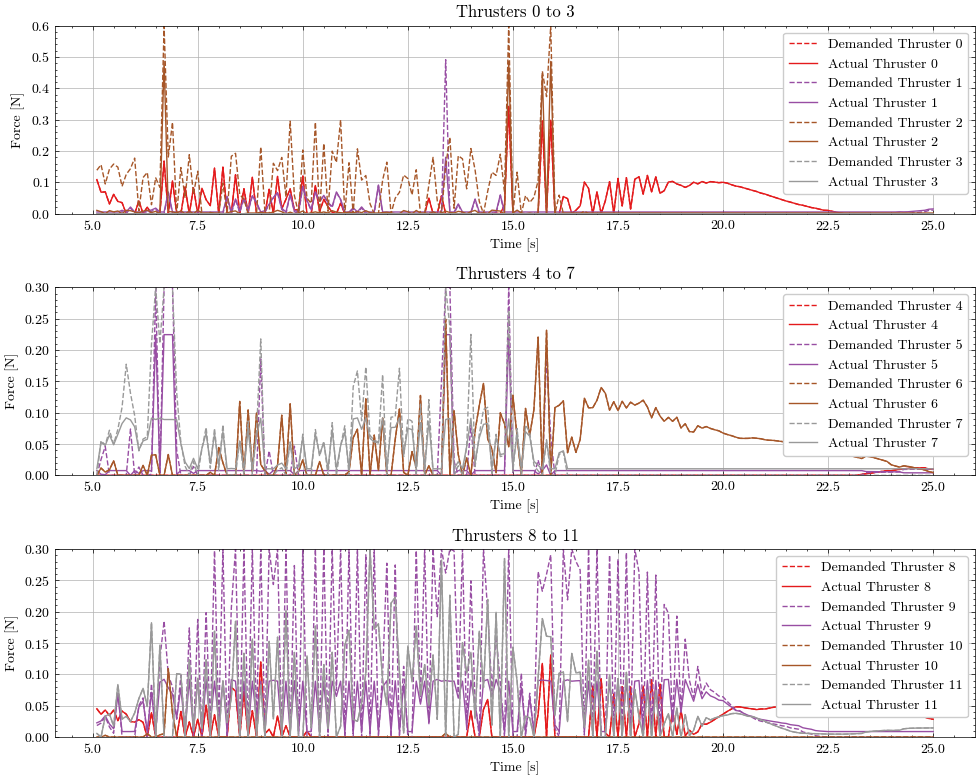

In [153]:
# Specify parameters
START_TIME = 5
END_TIME = 25

# Drop rows with NaNs in 'u_demanded', 'u_actual', or 'Timestamp'
df_clean = df[['Timestamp', 'u_demanded', 'u_actual']].dropna()

# Filter based on START_TIME and END_TIME
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    max_timestamp = df_clean['Timestamp'].max()
    if END_TIME > max_timestamp:
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
        END_TIME = max_timestamp
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

# Extract filtered data
timestamps_filtered = df_clean['Timestamp'].values
u_demanded_filtered = np.vstack(df_clean['u_demanded'].values)  # Stack u_demanded np.arrays into 2D array
u_actual_filtered = np.vstack(df_clean['u_actual'].values)  # Stack u_actual np.arrays into 2D array

# Create subplots for 12 thrusters (3 rows, 1 column, 4 thrusters per subplot)
fig, axs = plt.subplots(3, 1, figsize=(10, 8))

# Define a color map or list of colors (4 distinct colors)
colors = plt.cm.get_cmap('Set1', 4)  # Use only 4 colors since you want the same colors per subplot

# Plot thrusters in groups of 4
for i in range(3):
    ax = axs[i]
    start_thruster = i * 4
    end_thruster = start_thruster + 4

    # Plot demanded and actual forces for each thruster in the group
    for thruster in range(start_thruster, end_thruster):
        color = colors(thruster % 4)  # Reuse the same 4 colors for each subplot
        ax.plot(timestamps_filtered, u_demanded_filtered[:, thruster], label=f'Demanded Thruster {thruster}', linestyle='--', color=color)
        ax.plot(timestamps_filtered, u_actual_filtered[:, thruster], label=f'Actual Thruster {thruster}', linestyle='-', color=color)
    
    # Set the title and labels for each subplot
    ax.set_title(f'Thrusters {start_thruster} to {end_thruster-1}')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Force [N]')
    ax.legend(loc='upper right', facecolor='white', framealpha=1, frameon=True)
    ax.grid(True)
    if i == 0:
        ax.set_ylim((0,0.6))
    else:
        ax.set_ylim((0,0.3))

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Plot $l_2$ norm of demanded input


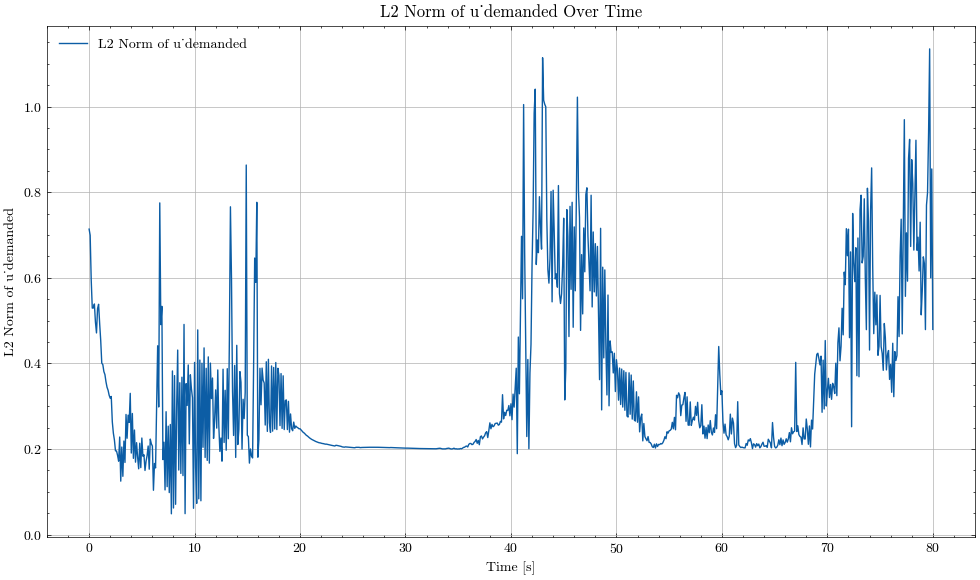

In [154]:
# Specify parameters
START_TIME = 0
END_TIME = 80

# Drop rows with NaNs in 'u_demanded' or 'Timestamp'
df_clean = df[['Timestamp', 'u_demanded']].dropna()

# Filter based on START_TIME and END_TIME
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    max_timestamp = df_clean['Timestamp'].max()
    if END_TIME > max_timestamp:
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

# Extract filtered data
timestamps_filtered = df_clean['Timestamp'].values
u_demanded_filtered = np.vstack(df_clean['u_demanded'].values)  # Stack u_demanded np.arrays into 2D array

# Compute the L2 norm of u_demanded at each timestep
l2_norm_u_demanded = np.linalg.norm(u_demanded_filtered, axis=1)

# Plot the L2 norm of u_demanded over time
plt.figure(figsize=(10, 6))
plt.plot(timestamps_filtered, l2_norm_u_demanded, label='L2 Norm of u_demanded', linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('L2 Norm of u_demanded')
plt.title('L2 Norm of u_demanded Over Time')
plt.grid(True)
plt.legend(loc='best')

# Show plot
plt.tight_layout()
plt.show()

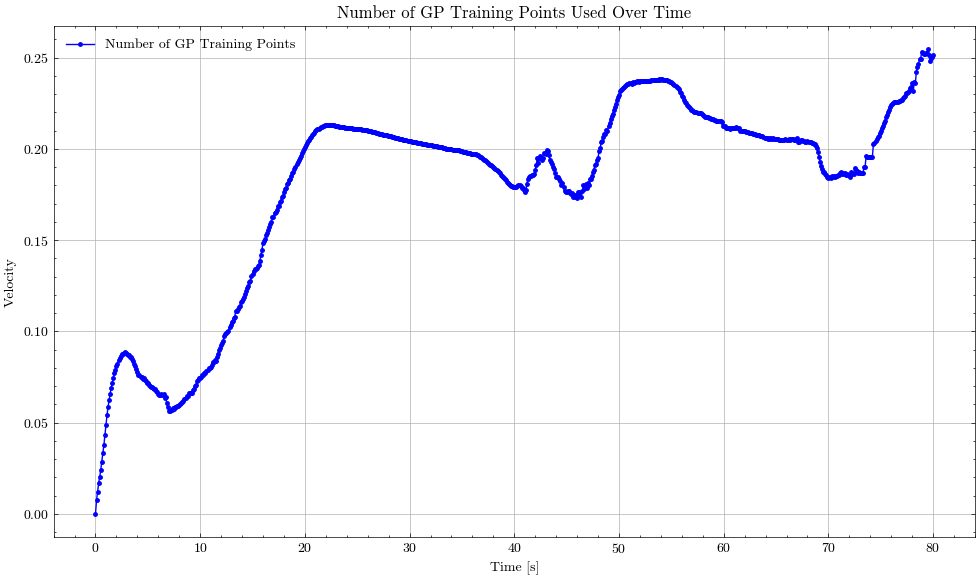

In [155]:
# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 20
END_TIME = 80

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'
df_clean = df[['Timestamp', 'velocity']].dropna()

# NOTE: Specify parameters here if you want
START_TIME = 0
END_TIME = 80

# Filter based on START_TIME and END_TIME
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    max_timestamp = df_clean['Timestamp'].max()
    if END_TIME > max_timestamp:
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

# Plot the number of training points used by GP over time
plt.figure(figsize=(10,6))
plt.plot(df_clean['Timestamp'], df_clean['velocity'], color='blue', marker='.', markersize=5, label='Number of GP Training Points', linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Velocity')
plt.title('Number of GP Training Points Used Over Time')
plt.grid(True)
plt.legend(loc='best')

# Show plot
plt.tight_layout()
plt.show()

## Number of training points in GP

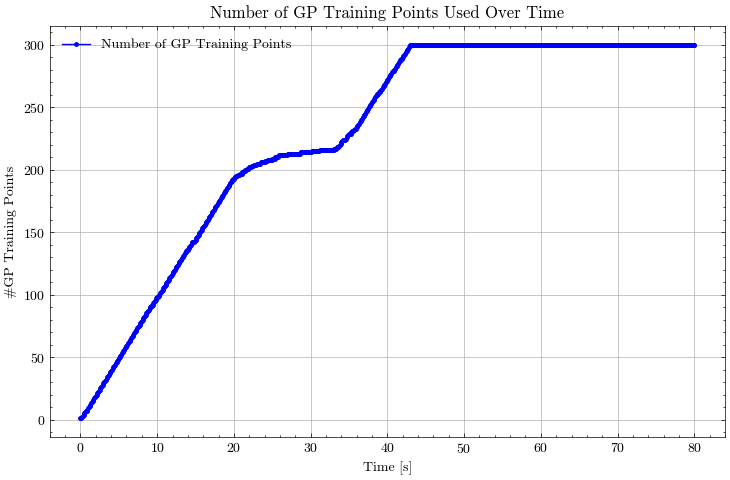

In [156]:
# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 20
END_TIME = 80

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'
df_clean = df[['Timestamp', 'n_points_GP']].dropna()

# NOTE: Specify parameters here if you want
START_TIME = 0
END_TIME = 80

# Filter based on START_TIME and END_TIME
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    max_timestamp = df_clean['Timestamp'].max()
    if END_TIME > max_timestamp:
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

# Plot the number of training points used by GP over time
plt.figure(figsize=(7.5,5))
plt.plot(df_clean['Timestamp'], df_clean['n_points_GP'], color='blue', marker='.', markersize=5, label='Number of GP Training Points', linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('#GP Training Points')
plt.title('Number of GP Training Points Used Over Time')
plt.grid(True)
plt.legend(loc='best')

# Show plot
plt.tight_layout()
plt.show()

## Cumulative MPC Closed-Loop Cost
This plots shows the cumulative closed-loop cost of the MPC. It sums up the cost generated at stage 0 over the entirety of the simulation.

/var/folders/c7/b11r62m15nx9rplq1yc4p5qw0000gq/T/ipykernel_2585/4223108416.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


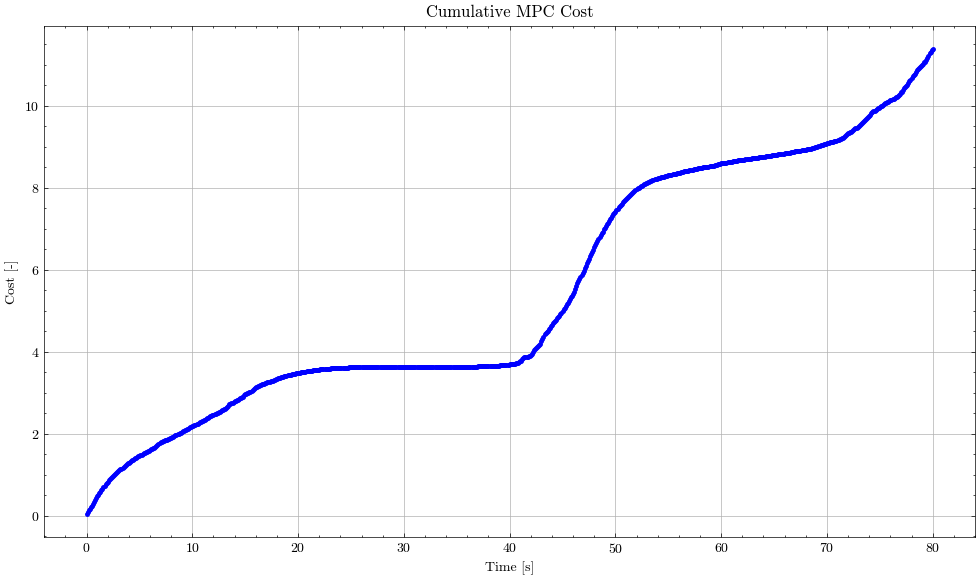

In [157]:
# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 20
END_TIME = 80

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'
df_clean = df[['Timestamp', 'mpc_cost']].dropna()
df_clean['mpc_cost'] += 5e-2 * 0.2
df_clean['cumulative_cost'] = df_clean['mpc_cost'].cumsum()

# NOTE: Specify parameters here if you want
START_TIME = 0
END_TIME = 80

# Filter based on START_TIME and END_TIME
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    max_timestamp = df_clean['Timestamp'].max()
    if END_TIME > max_timestamp:
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

# Plot the number of training points used by GP over time
plt.figure(figsize=(10,6))
plt.plot(df_clean['Timestamp'], df_clean['cumulative_cost'], color='blue', marker='.', markersize=5, linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Cost [-]')
plt.title('Cumulative MPC Cost')
plt.grid(True)
plt.legend(loc='best')

# Show plot
plt.tight_layout()
plt.show()

## Create an interactive Video

Import the frames and save them in a variable

In [158]:
df_clean_video = df[['Timestamp', 'frames']].dropna()[1:].reset_index(drop=True)
print(df_clean_video)

KeyError: "['frames'] not in index"

In [132]:
# Load the rest of the data
df_clean = df[['Timestamp', 'n_points_GP', 'e_gp', 'e_nom', 'tracking_error', 'attitude_error', 'u_demanded', 'u_actual', 'mpc_cost', 'velocity']].dropna().reset_index(drop=True)
df_clean['mpc_cost'] += 5e-2 * 0.2
df_clean['cumulative_cost'] = df_clean['mpc_cost'].cumsum()
print(df_clean)

      Timestamp  n_points_GP      e_gp     e_nom  tracking_error  \
0           0.0            1  0.000000  0.000000        0.506917   
1           0.1            1  0.016128  0.016128        0.506817   
2           0.2            2  0.013216  0.027671        0.506516   
3           0.3            3  0.015559  0.016855        0.505847   
4           0.4            4  0.004145  0.017294        0.504692   
...         ...          ...       ...       ...             ...   
1006      100.6          263  0.000040  0.000896        0.067643   
1007      100.7          264  0.000076  0.003694        0.067593   
1008      100.8          265  0.000056  0.000893        0.067540   
1009      100.9          266  0.000054  0.004335        0.067486   
1010      101.0          267  0.000064  0.000826        0.067429   

      attitude_error                                         u_demanded  \
0          49.276038  [7.032311097450142e-08, 0.4309192852417208, 1....   
1          49.256059  [0.03843079

KeyboardInterrupt: 

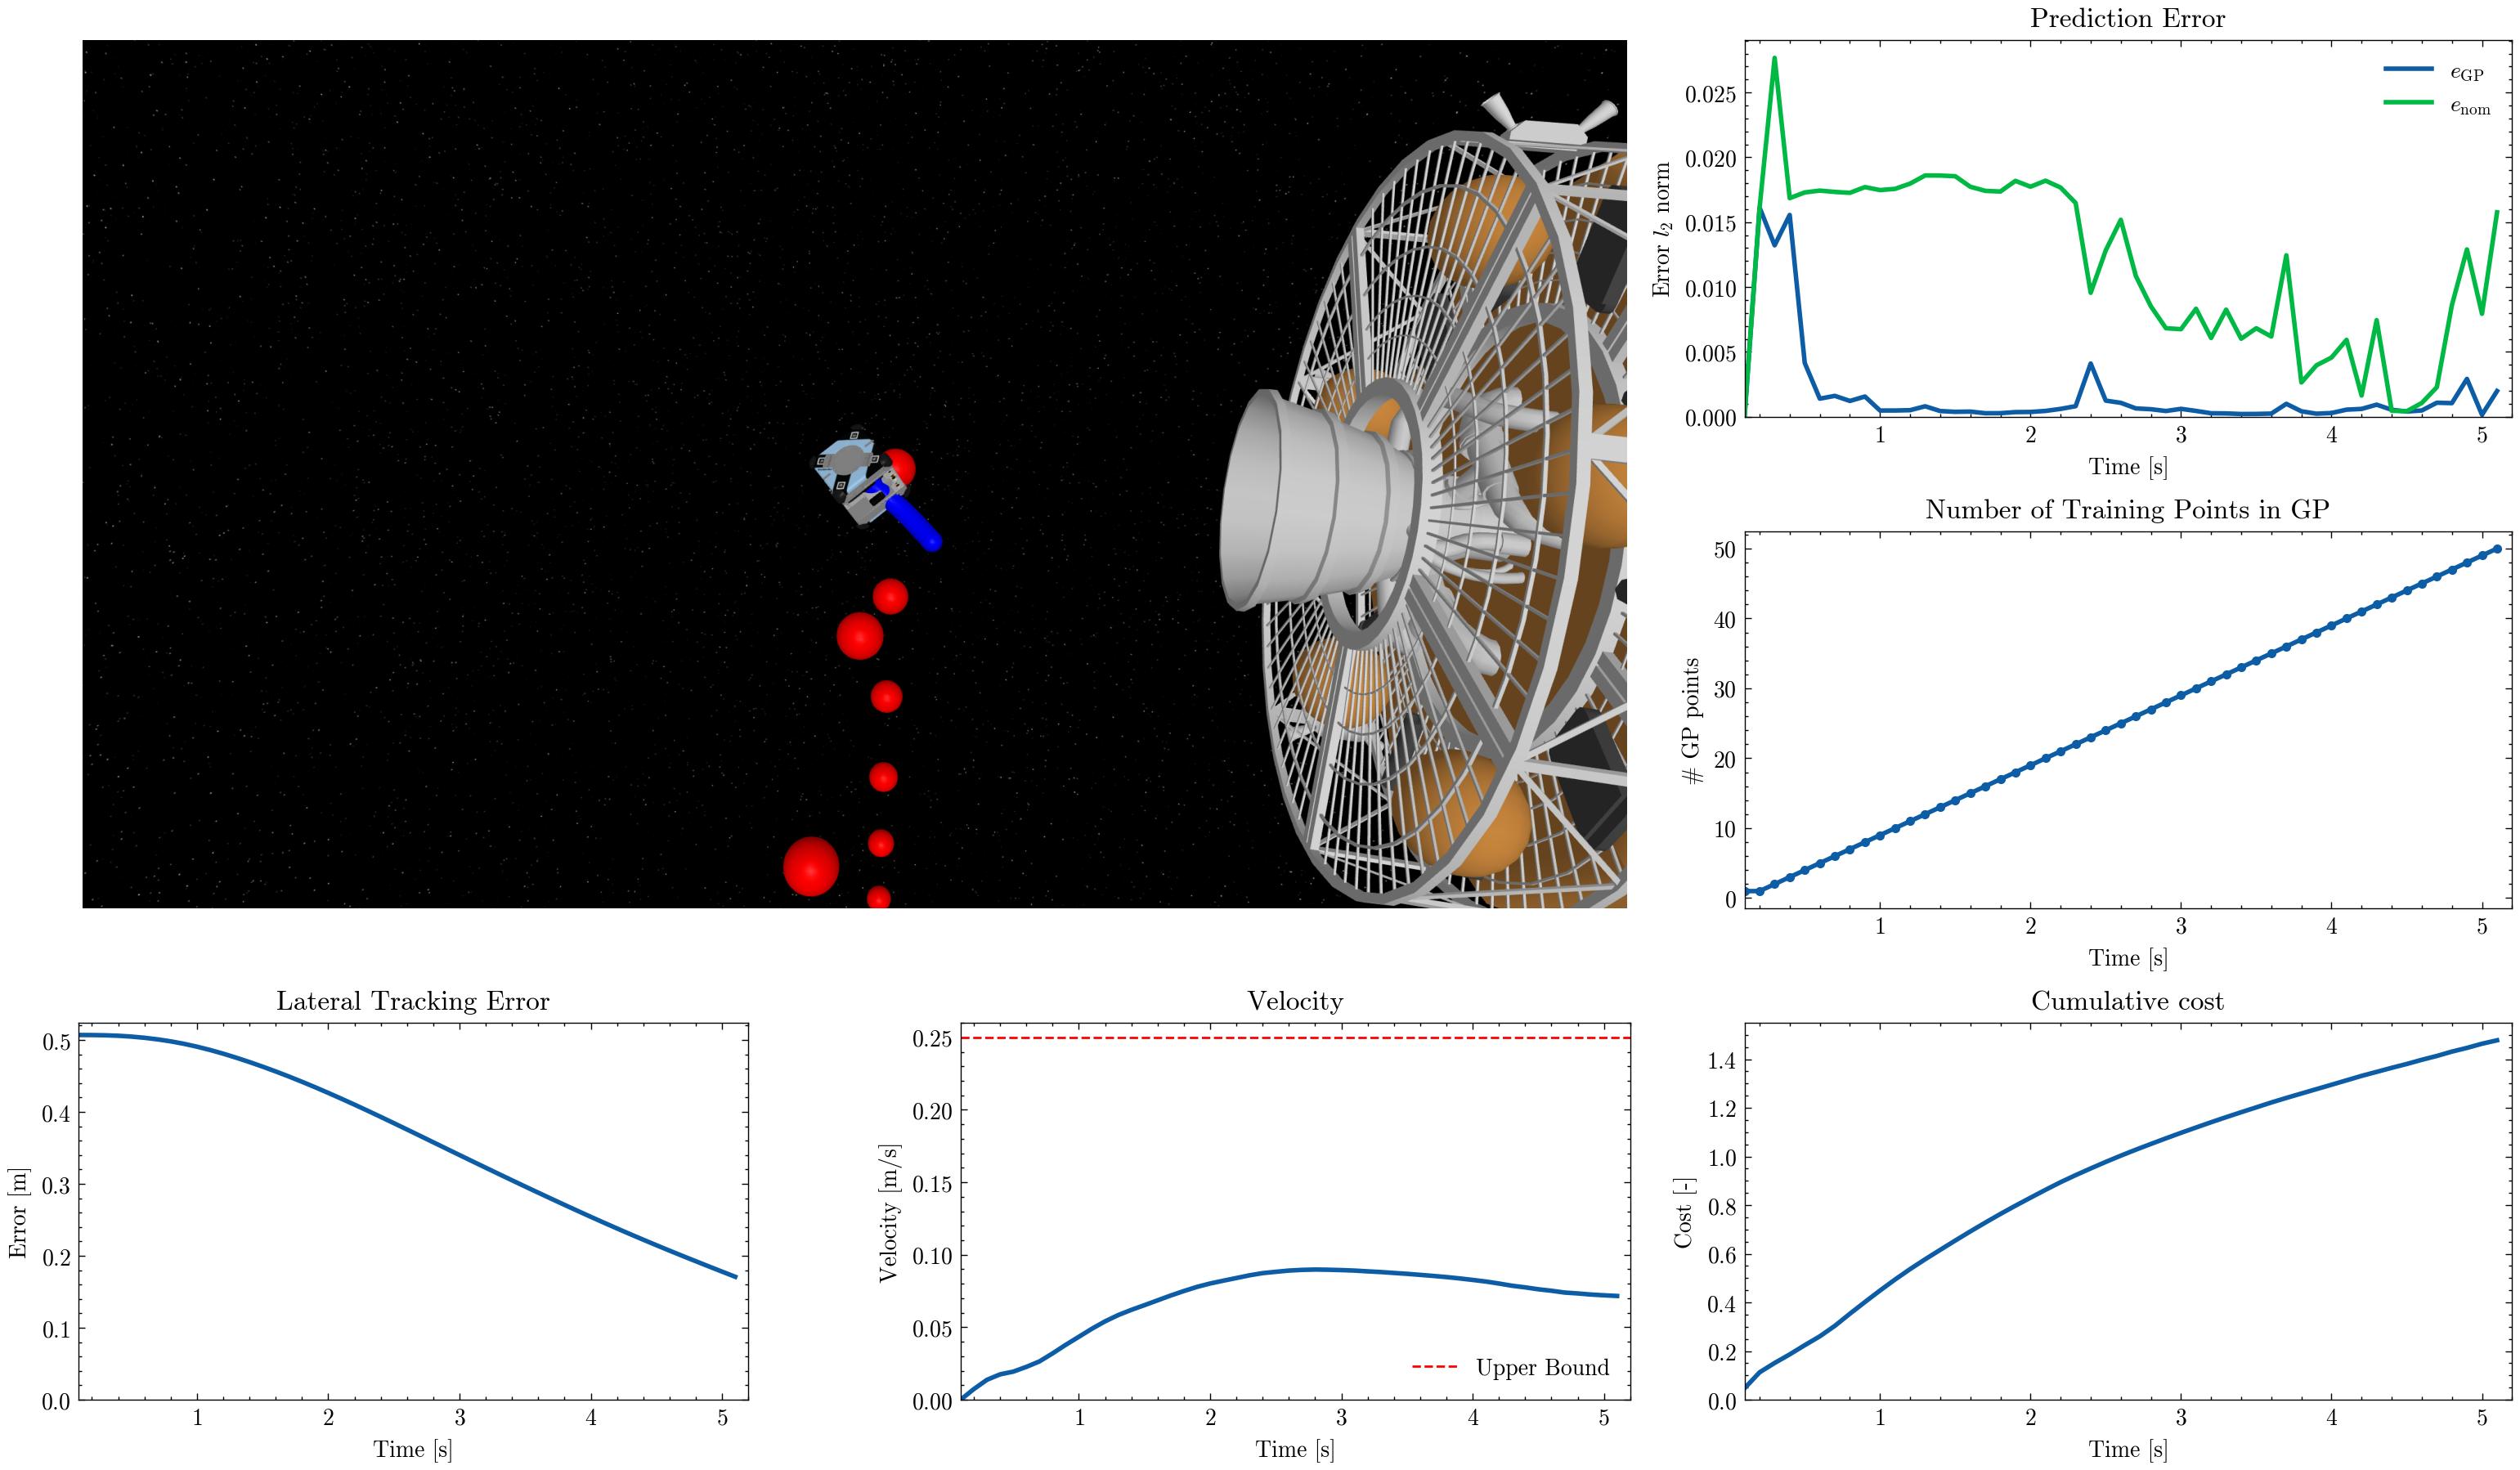

In [133]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
import numpy as np
import cv2  # Only needed for cv2.cvtColor

# Example DataFrame with video frames and timestamps
timestamps = df_clean_video['Timestamp'].values
n_points_GP = df_clean['n_points_GP'].values
e_gp = df_clean['e_gp'].values
e_nom = df_clean['e_nom'].values
tracking_error = df_clean['tracking_error'].values
attitude_error = df_clean['attitude_error'].values
u_demanded = df_clean['u_demanded'].values
u_actual = df_clean['u_actual'].values
mpc_cost = df_clean['mpc_cost'].values
cumulative_cost = df_clean['cumulative_cost'].values
velocity = df_clean['velocity'].values

# Extract data for a specific thruster
thruster_idx = 0
u_demanded_i = np.array([u[thruster_idx] for u in u_demanded])
u_actual_i = np.array([u[thruster_idx] for u in u_actual])

# Create the figure and GridSpec layout
fig = plt.figure(figsize=(19.2, 10.8), dpi=200)
gs = GridSpec(14, 25)  # Create a grid with 6 rows and 6 columns

# Subplot for video frames (large top-left area)
ax_video = fig.add_subplot(gs[0:9, 0:16])  # Spanning 9 rows and 16 columns (more horizontal space)
ax_video.axis('off')  # Remove axes for the video

# Two smaller plots stacked to the right of the video
ax_plot_right_top = fig.add_subplot(gs[0:4, 17:25])  # First small plot to the right of the video
ax_plot_right_top.set_title("Prediction Error")

ax_plot_right_bottom = fig.add_subplot(gs[5:9, 17:25])  # Second small plot to the right of the video
ax_plot_right_bottom.set_title("Number of Training Points in GP")

# Two plots side by side below the video (bottom left)
ax_bottom_left_1 = fig.add_subplot(gs[10:14, 0:7])  # First plot below the video
ax_bottom_left_1.set_title("Lateral Tracking Error")

ax_bottom_left_2 = fig.add_subplot(gs[10:14, 9:16])  # Second plot below the video
ax_bottom_left_2.set_title("Attitude Error")

# One plot in the bottom right corner (below the stacked plots)
ax_bottom_right = fig.add_subplot(gs[10:14, 17:25])  # Plot in the bottom right corner
ax_bottom_right.set_title(f"Demanded vs. Actual Thrust of Thruster {thruster_idx}")


def get_sliding_window_idx(frame, window_size):
    return max(0, frame - window_size), min(frame + 1, len(df_clean_video))


# Update function for each frame
def update(frame):
    # Get the current video frame from the DataFrame
    video_frame = df_clean_video['frames'].iloc[frame]

    # Update video subplot
    ax_video.clear()
    ax_video.axis('off')  # Hide axes for the video
    if video_frame is not None:
        ax_video.imshow(video_frame)  # Display video frame

    # Update the right top plot
    start_idx, end_idx = get_sliding_window_idx(frame, 200)
    ax_plot_right_top.clear()
    ax_plot_right_top.set_title("Prediction Error")
    ax_plot_right_top.plot(timestamps[start_idx:end_idx], e_gp[start_idx:end_idx], lw=2, label=r'$e_{\text{GP}}$')
    ax_plot_right_top.plot(timestamps[start_idx:end_idx], e_nom[start_idx:end_idx], lw=2, label=r'$e_{\text{nom}}$')
    ax_plot_right_top.set_xlim(timestamps[start_idx], timestamps[end_idx])
    ax_plot_right_top.set_xlabel("Time [s]")
    ax_plot_right_top.set_ylabel(r"Error $l_2$ norm")
    ax_plot_right_top.set_ylim(bottom=0)
    ax_plot_right_top.legend(loc='best')

    # Update the right bottom plot
    start_idx, end_idx = get_sliding_window_idx(frame, 500)
    ax_plot_right_bottom.clear()
    ax_plot_right_bottom.set_title("Number of Training Points in GP")
    ax_plot_right_bottom.plot(timestamps[start_idx:end_idx], n_points_GP[start_idx:end_idx], lw=2, marker='.')
    ax_plot_right_bottom.set_xlim(timestamps[start_idx], timestamps[end_idx])
    ax_plot_right_bottom.set_xlabel("Time [s]")
    ax_plot_right_bottom.set_ylabel("# GP points")
    ax_bottom_right.set_ylim((0,300))

    # Update bottom left plot 1
    start_idx, end_idx = get_sliding_window_idx(frame, 100)
    ax_bottom_left_1.clear()
    ax_bottom_left_1.set_title("Lateral Tracking Error")
    ax_bottom_left_1.plot(timestamps[start_idx:end_idx], tracking_error[start_idx:end_idx], lw=2)
    ax_bottom_left_1.set_xlim(timestamps[start_idx], timestamps[end_idx])
    ax_bottom_left_1.set_xlabel("Time [s]")
    ax_bottom_left_1.set_ylabel("Error [m]")
    ax_bottom_left_1.set_ylim(bottom=0)

    # Update bottom left plot 2
    ax_bottom_left_2.clear()
    ax_bottom_left_2.set_title("Velocity")
    ax_bottom_left_2.plot(timestamps[start_idx:end_idx], velocity[start_idx:end_idx], lw=2)
    ax_bottom_left_2.set_xlim(timestamps[start_idx], timestamps[end_idx])
    ax_bottom_left_2.set_xlabel("Time [s]")
    ax_bottom_left_2.set_ylabel("Velocity [m/s]")
    ax_bottom_left_2.set_ylim(bottom=0, top= 0.26)
    ax_bottom_left_2.axhline(y=0.25, color='red', linestyle='--', label='Upper Bound')
    ax_bottom_left_2.legend(loc='best')

    # Update bottom right plot
    start_idx, end_idx = get_sliding_window_idx(frame, 500)
    ax_bottom_right.clear()
    ax_bottom_right.set_title(f"Cumulative cost")
    ax_bottom_right.plot(timestamps[start_idx:end_idx], cumulative_cost[start_idx:end_idx], lw=2)
    ax_bottom_right.set_xlim(timestamps[start_idx], timestamps[end_idx])
    ax_bottom_right.set_xlabel("Time [s]")
    ax_bottom_right.set_ylabel("Cost [-]")
    ax_bottom_right.set_ylim(bottom=0)
    ax_plot_right_top.legend(loc='best')

# Create the animation using FuncAnimation
ani = FuncAnimation(fig, update, frames=len(df_clean_video)-1, repeat=False)

# Save the animation as a video file
ani.save('output_video.mp4', fps=30, extra_args=['-vcodec', 'libx264'])

print("Video saved as output_video.mp4")

## Notes

2024-09-21_10:43:42 
Thruster 0 SO
Thruster 2 5 7 Faulty
Interesting because of huge error residual at 14.5s. Might be because of errors before that.